# Setup

In [1]:
!pip -q install pyarrow spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 79.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# imports

In [3]:
import os
import re
import gc
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from pathlib import Path
from tqdm.auto import tqdm
from difflib import SequenceMatcher

from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42
TARGET_PAIRS = 150000
MAX_FEATURES = 100000
N_SPLITS = 5

OUTPUT_DIR = Path("wikiauto_sample150k_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

READABILITY_COLS = [
    "sentence_len",
    "avg_word_len",
    "type_token_ratio",
    "char_len",
    "punctuation_ratio"
]

VARIANT_COLS = [
    "same_ratio",
    "replace_ratio",
    "insert_ratio",
    "delete_ratio",
    "compression_ratio",
    "length_diff_ratio"
]

ENHANCED_COLS = [
    "lemma_ratio",
    "pos_ratio"
]

# Getting the DS

In [4]:
!wget -q "https://raw.githubusercontent.com/chaojiang06/wiki-auto/master/wiki-auto/ACL2020/train.src" -O train.src
!wget -q "https://raw.githubusercontent.com/chaojiang06/wiki-auto/master/wiki-auto/ACL2020/train.dst" -O train.dst

print("Downloaded train.src and train.dst")

Downloaded train.src and train.dst


# Load and Clean Pairs

In [5]:
def clean_wikiauto_text(text):
    text = str(text)
    replacements = {
        "-LRB-": "(",
        "-RRB-": ")",
        "-LSB-": "[",
        "-RSB-": "]",
        "-LCB-": "{",
        "-RCB-": "}",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([,.;:!?%)\]])", r"\1", text)
    text = re.sub(r"([(\[])\s+", r"\1", text)

    return text.strip()


with open("train.src", "r", encoding="utf-8") as f:
    normal = [line.strip() for line in f.readlines()]

with open("train.dst", "r", encoding="utf-8") as f:
    simple = [line.strip() for line in f.readlines()]

assert len(normal) == len(simple)

pairs_full = pd.DataFrame({
    "Normal": normal,
    "Simple": simple
})

pairs_full["Normal"] = pairs_full["Normal"].apply(clean_wikiauto_text)
pairs_full["Simple"] = pairs_full["Simple"].apply(clean_wikiauto_text)

pairs_full["normal_word_len"] = pairs_full["Normal"].str.split().apply(len)
pairs_full["simple_word_len"] = pairs_full["Simple"].str.split().apply(len)

pairs_full = pairs_full[
    (pairs_full["Normal"].str.len() > 10) &
    (pairs_full["Simple"].str.len() > 10) &
    (pairs_full["normal_word_len"].between(5, 60)) &
    (pairs_full["simple_word_len"].between(5, 60))
].copy()

pairs_full = pairs_full.reset_index(drop=True)

print("Filtered full pairs:", pairs_full.shape)
display(pairs_full.head())

Filtered full pairs: (479586, 4)


,Normal,Simple,normal_word_len,simple_word_len
0,"A romantic friendship, passionate friendship, ...","A romantic friendship, passionate friendship o...",35,26
1,Rocky Balboa is a 2006 American boxing sports ...,Rocky Balboa (also known as Rocky VI) is the s...,17,24
2,Janakinath Bose (28 May 1860 – 1934) was an In...,Janakinath Bose (28 May 1860 – 1934) was an In...,24,21
3,Bionics or biologically inspired engineering i...,Bionics (also known as biomimetics) is the sci...,27,15
4,The Ilyushin Il-18 (; NATO reporting name: Coo...,Ilyushin Il-18 (Russian: Илью ́ шин Ил-18; NAT...,32,20


# Sampling WikiAuto Pairs

In [6]:
if len(pairs_full) > TARGET_PAIRS:
    pairs_wikiauto = pairs_full.sample(
        n=TARGET_PAIRS,
        random_state=RANDOM_STATE
    ).copy()
else:
    pairs_wikiauto = pairs_full.copy()

pairs_wikiauto = pairs_wikiauto.reset_index(drop=True)
pairs_wikiauto["pair_id"] = np.arange(len(pairs_wikiauto))
pairs_wikiauto["dataset"] = "WikiAuto"

pairs_wikiauto = pairs_wikiauto[
    ["dataset", "pair_id", "Normal", "Simple"]
].copy()

pairs_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_pairs_sample150k.parquet",
    index=False
)

print("Sampled pairs:", pairs_wikiauto.shape)
display(pairs_wikiauto.head())

del pairs_full
gc.collect()

Sampled pairs: (150000, 4)


,dataset,pair_id,Normal,Simple
0,WikiAuto,0,Julien Simon-Chautemps (born 14 May 1978) is a...,Julien Simon-Chautemps (born 14 May 1978) is a...
1,WikiAuto,1,"In 1997, the Trans Sport added the Montana mon...","Since 1997, its most popular trim package had ..."
2,WikiAuto,2,Christopher Livingstone Eubank (born 8 August ...,Christopher Livingstone Eubank Sr. (born 8 Aug...
3,WikiAuto,3,"In July 2016, WWE reintroduced the brand split...",The brand split was brought back in July of 20...
4,WikiAuto,4,"Lebanon is a town in Potter County, South Dako...",It is in Potter County.


37

# Building Classification DS

In [7]:
def build_classification_pairs(df, normal_col="Normal", simple_col="Simple", dataset_name="WikiAuto"):
    df = df[[normal_col, simple_col]].copy()
    df = df.dropna()

    df[normal_col] = df[normal_col].astype(str).str.strip()
    df[simple_col] = df[simple_col].astype(str).str.strip()

    df = df[
        (df[normal_col] != "") &
        (df[simple_col] != "")
    ].reset_index(drop=True)

    df["pair_id"] = np.arange(len(df))
    df["dataset"] = dataset_name

    normal_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[normal_col],
        "label": 0,
        "label_name": "normal",
        "paired_text": df[simple_col]
    })

    simple_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[simple_col],
        "label": 1,
        "label_name": "simplified",
        "paired_text": df[normal_col]
    })

    clf_df = pd.concat(
        [normal_df, simple_df],
        ignore_index=True
    )

    return df, clf_df


pairs_wikiauto_clean, clf_wikiauto = build_classification_pairs(
    pairs_wikiauto,
    normal_col="Normal",
    simple_col="Simple",
    dataset_name="WikiAuto"
)

clf_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_classification_sample150k.parquet",
    index=False
)

print("Pairs clean:", pairs_wikiauto_clean.shape)
print("Classification dataset:", clf_wikiauto.shape)
display(clf_wikiauto["label_name"].value_counts())
display(clf_wikiauto.head())

Pairs clean: (150000, 4)
Classification dataset: (300000, 6)


label_name
normal        150000
simplified    150000
Name: count, dtype: int64

,dataset,pair_id,text,label,label_name,paired_text
0,WikiAuto,0,Julien Simon-Chautemps (born 14 May 1978) is a...,0,normal,Julien Simon-Chautemps (born 14 May 1978) is a...
1,WikiAuto,1,"In 1997, the Trans Sport added the Montana mon...",0,normal,"Since 1997, its most popular trim package had ..."
2,WikiAuto,2,Christopher Livingstone Eubank (born 8 August ...,0,normal,Christopher Livingstone Eubank Sr. (born 8 Aug...
3,WikiAuto,3,"In July 2016, WWE reintroduced the brand split...",0,normal,The brand split was brought back in July of 20...
4,WikiAuto,4,"Lebanon is a town in Potter County, South Dako...",0,normal,It is in Potter County.


# Pair-Aware Leakage Check

In [8]:
X = clf_wikiauto["text"]
y = clf_wikiauto["label"]
groups = clf_wikiauto["pair_id"]

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups), 1):
    train_pairs = set(clf_wikiauto.iloc[train_idx]["pair_id"])
    test_pairs = set(clf_wikiauto.iloc[test_idx]["pair_id"])
    overlap = train_pairs.intersection(test_pairs)

    print(f"Fold {fold}")
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Train label distribution:")
    print(clf_wikiauto.iloc[train_idx]["label_name"].value_counts(normalize=True))
    print("Test label distribution:")
    print(clf_wikiauto.iloc[test_idx]["label_name"].value_counts(normalize=True))
    print("Pair leakage:", len(overlap))
    print("-" * 50)

Fold 1
Train size: 240000
Test size: 60000
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 2
Train size: 240000
Test size: 60000
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 3
Train size: 240000
Test size: 60000
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Pair leakage: 0
--------------------------------------------------
Fold 4
Train size: 240000
Test size: 

# Readability Features

In [9]:
def tokenize_words(text):
    return re.findall(r"\b\w+\b", str(text).lower())


def extract_readability_features(clf_df):
    df = clf_df[
        ["dataset", "pair_id", "text", "label", "label_name"]
    ].copy()

    words = df["text"].apply(tokenize_words)

    df["sentence_len"] = words.apply(len)

    df["avg_word_len"] = words.apply(
        lambda toks: np.mean([len(w) for w in toks]) if toks else 0
    )

    df["type_token_ratio"] = words.apply(
        lambda toks: len(set(toks)) / len(toks) if toks else 0
    )

    df["char_len"] = df["text"].astype(str).str.len()

    df["punctuation_ratio"] = df["text"].apply(
        lambda txt:
            sum(ch in string.punctuation for ch in str(txt))
            / max(len(str(txt)), 1)
    )

    return df


readability_wikiauto = extract_readability_features(clf_wikiauto)

readability_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_readability_sample150k.parquet",
    index=False
)

print(readability_wikiauto.shape)
display(readability_wikiauto.head())

display(
    readability_wikiauto.groupby("label_name")[READABILITY_COLS].mean()
)

(300000, 10)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio
0,WikiAuto,0,Julien Simon-Chautemps (born 14 May 1978) is a...,0,normal,13,4.692308,1.000000,76,0.052632
1,WikiAuto,1,"In 1997, the Trans Sport added the Montana mon...",0,normal,16,4.437500,0.937500,88,0.022727
2,WikiAuto,2,Christopher Livingstone Eubank (born 8 August ...,0,normal,19,5.315789,1.000000,122,0.024590
3,WikiAuto,3,"In July 2016, WWE reintroduced the brand split...",0,normal,21,5.285714,0.857143,135,0.037037
4,WikiAuto,4,"Lebanon is a town in Potter County, South Dako...",0,normal,11,4.636364,1.000000,64,0.046875


,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio
label_name,,,,,
normal,22.512520,4.805749,0.898102,134.70598,0.033251
simplified,15.976387,4.626398,0.927873,92.55592,0.033868


# Variant Features

In [10]:
def sequence_op_features(normal_text, simple_text):
    normal_tokens = tokenize_words(normal_text)
    simple_tokens = tokenize_words(simple_text)

    matcher = SequenceMatcher(None, normal_tokens, simple_tokens)

    same = replace = insert = delete = 0

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            same += max(i2 - i1, j2 - j1)
        elif tag == "replace":
            replace += max(i2 - i1, j2 - j1)
        elif tag == "insert":
            insert += (j2 - j1)
        elif tag == "delete":
            delete += (i2 - i1)

    total = same + replace + insert + delete

    normal_len = len(normal_tokens)
    simple_len = len(simple_tokens)

    return {
        "same_ratio": same / total if total else 0,
        "replace_ratio": replace / total if total else 0,
        "insert_ratio": insert / total if total else 0,
        "delete_ratio": delete / total if total else 0,
        "compression_ratio": simple_len / normal_len if normal_len else 0,
        "length_diff_ratio": (normal_len - simple_len) / normal_len if normal_len else 0,
    }


def extract_variant_features(pairs_df, normal_col="Normal", simple_col="Simple"):
    rows = []

    for row in tqdm(
        pairs_df.itertuples(index=False),
        total=len(pairs_df)
    ):
        feats = sequence_op_features(
            getattr(row, normal_col),
            getattr(row, simple_col)
        )

        feats["dataset"] = row.dataset
        feats["pair_id"] = row.pair_id

        rows.append(feats)

    return pd.DataFrame(rows)


variant_wikiauto = extract_variant_features(
    pairs_wikiauto_clean,
    normal_col="Normal",
    simple_col="Simple"
)

variant_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_variant_sample150k.parquet",
    index=False
)

print(variant_wikiauto.shape)
display(variant_wikiauto.head())
display(variant_wikiauto.describe())

  0%|          | 0/150000 [00:00<?, ?it/s]

(150000, 8)


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,dataset,pair_id
0,0.526316,0.157895,0.315789,0.000000,1.307692,-0.307692,WikiAuto,0
1,0.210526,0.789474,0.000000,0.000000,0.812500,0.187500,WikiAuto,1
2,0.650000,0.000000,0.050000,0.300000,0.736842,0.263158,WikiAuto,2
3,0.272727,0.333333,0.242424,0.151515,1.190476,-0.190476,WikiAuto,3
4,0.363636,0.090909,0.000000,0.545455,0.454545,0.545455,WikiAuto,4


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,pair_id
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.458324,0.267128,0.059666,0.214882,0.782722,0.217278,74999.500000
std,0.224524,0.241968,0.109805,0.225083,0.371689,0.371689,43301.414527
min,0.024390,0.000000,0.000000,0.000000,0.151515,-5.800000,0.000000
25%,0.277778,0.051282,0.000000,0.000000,0.500000,0.000000,37499.750000
50%,0.409091,0.200000,0.000000,0.137931,0.733333,0.266667,74999.500000
75%,0.608696,0.451613,0.076923,0.391304,1.000000,0.500000,112499.250000
max,1.000000,0.973684,0.852941,0.848485,6.800000,0.848485,149999.000000


# Enhanced Features

In [11]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["ner", "parser"]
)


def doc_to_features(doc):
    return [
        {
            "text": token.text.lower(),
            "lemma": token.lemma_.lower(),
            "pos": token.pos_
        }
        for token in doc
        if not token.is_space and not token.is_punct
    ]


def enhanced_features_from_docs(normal_tokens, simple_tokens):
    normal_words = [t["text"] for t in normal_tokens]
    simple_words = [t["text"] for t in simple_tokens]

    matcher = SequenceMatcher(None, normal_words, simple_words)

    lemma_same = 0
    lemma_total = 0

    pos_same = 0
    pos_total = 0

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "replace":
            normal_span = normal_tokens[i1:i2]
            simple_span = simple_tokens[j1:j2]

            length = min(len(normal_span), len(simple_span))

            for k in range(length):
                lemma_total += 1
                pos_total += 1

                if normal_span[k]["lemma"] == simple_span[k]["lemma"]:
                    lemma_same += 1

                if normal_span[k]["pos"] == simple_span[k]["pos"]:
                    pos_same += 1

    return {
        "lemma_ratio": lemma_same / lemma_total if lemma_total else 0,
        "pos_ratio": pos_same / pos_total if pos_total else 0,
    }


def extract_enhanced_features_streaming(pairs_df, batch_size=1000):
    rows = []

    total = len(pairs_df)

    for start in tqdm(range(0, total, batch_size)):
        batch = pairs_df.iloc[start:start + batch_size]

        normal_texts = batch["Normal"].astype(str).tolist()
        simple_texts = batch["Simple"].astype(str).tolist()

        normal_docs = [
            doc_to_features(doc)
            for doc in nlp.pipe(normal_texts, batch_size=batch_size)
        ]

        simple_docs = [
            doc_to_features(doc)
            for doc in nlp.pipe(simple_texts, batch_size=batch_size)
        ]

        for local_i, row in enumerate(batch.itertuples(index=False)):
            feats = enhanced_features_from_docs(
                normal_docs[local_i],
                simple_docs[local_i]
            )

            feats["dataset"] = row.dataset
            feats["pair_id"] = row.pair_id

            rows.append(feats)

        del normal_docs
        del simple_docs
        gc.collect()

    return pd.DataFrame(rows)


enhanced_wikiauto = extract_enhanced_features_streaming(
    pairs_wikiauto_clean,
    batch_size=1000
)

enhanced_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_enhanced_sample150k.parquet",
    index=False
)

print(enhanced_wikiauto.shape)
display(enhanced_wikiauto.head())
display(enhanced_wikiauto.describe())

  0%|          | 0/150 [00:00<?, ?it/s]

(150000, 4)


,lemma_ratio,pos_ratio,dataset,pair_id
0,0.00,0.000000,WikiAuto,0
1,0.00,0.166667,WikiAuto,1
2,0.00,0.000000,WikiAuto,2
3,0.25,0.250000,WikiAuto,3
4,0.00,0.000000,WikiAuto,4


,lemma_ratio,pos_ratio,pair_id
count,150000.000000,150000.000000,150000.000000
mean,0.021393,0.301148,74999.500000
std,0.114352,0.370601,43301.414527
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,37499.750000
50%,0.000000,0.111111,74999.500000
75%,0.000000,0.500000,112499.250000
max,1.000000,1.000000,149999.000000


# Merge Features

In [12]:
def merge_features(clf_df, readability_df, variant_df=None, enhanced_df=None):
    base = clf_df[
        ["dataset", "pair_id", "text", "label", "label_name"]
    ].copy()

    base = base.merge(
        readability_df[
            ["dataset", "pair_id", "text", "label"] + READABILITY_COLS
        ],
        on=["dataset", "pair_id", "text", "label"],
        how="left"
    )

    if variant_df is not None:
        base = base.merge(
            variant_df[
                ["dataset", "pair_id"] + VARIANT_COLS
            ],
            on=["dataset", "pair_id"],
            how="left"
        )

    if enhanced_df is not None:
        base = base.merge(
            enhanced_df[
                ["dataset", "pair_id"] + ENHANCED_COLS
            ],
            on=["dataset", "pair_id"],
            how="left"
        )

    return base


model_df_wikiauto = merge_features(
    clf_wikiauto,
    readability_wikiauto,
    variant_wikiauto,
    enhanced_wikiauto
)

model_df_wikiauto.to_parquet(
    OUTPUT_DIR / "wikiauto_model_df_sample150k.parquet",
    index=False
)

print(model_df_wikiauto.shape)
display(model_df_wikiauto.head())
print(model_df_wikiauto.isna().sum())

del readability_wikiauto
del variant_wikiauto
del enhanced_wikiauto
gc.collect()

(300000, 18)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,lemma_ratio,pos_ratio
0,WikiAuto,0,Julien Simon-Chautemps (born 14 May 1978) is a...,0,normal,13,4.692308,1.000000,76,0.052632,0.526316,0.157895,0.315789,0.000000,1.307692,-0.307692,0.00,0.000000
1,WikiAuto,1,"In 1997, the Trans Sport added the Montana mon...",0,normal,16,4.437500,0.937500,88,0.022727,0.210526,0.789474,0.000000,0.000000,0.812500,0.187500,0.00,0.166667
2,WikiAuto,2,Christopher Livingstone Eubank (born 8 August ...,0,normal,19,5.315789,1.000000,122,0.024590,0.650000,0.000000,0.050000,0.300000,0.736842,0.263158,0.00,0.000000
3,WikiAuto,3,"In July 2016, WWE reintroduced the brand split...",0,normal,21,5.285714,0.857143,135,0.037037,0.272727,0.333333,0.242424,0.151515,1.190476,-0.190476,0.25,0.250000
4,WikiAuto,4,"Lebanon is a town in Potter County, South Dako...",0,normal,11,4.636364,1.000000,64,0.046875,0.363636,0.090909,0.000000,0.545455,0.454545,0.545455,0.00,0.000000


dataset              0
pair_id              0
text                 0
label                0
label_name           0
sentence_len         0
avg_word_len         0
type_token_ratio     0
char_len             0
punctuation_ratio    0
same_ratio           0
replace_ratio        0
insert_ratio         0
delete_ratio         0
compression_ratio    0
length_diff_ratio    0
lemma_ratio          0
pos_ratio            0
dtype: int64


49

# Evaluation

In [13]:
CONFIGS = [
    ("Baseline: Char TF-IDF + LinearSVC", []),
    ("Baseline + Readability", READABILITY_COLS),
    ("Baseline + Readability + Variant", READABILITY_COLS + VARIANT_COLS),
    ("Baseline + Readability + Variant + Enhanced", READABILITY_COLS + VARIANT_COLS + ENHANCED_COLS),
]


def evaluate_all_configs_fast(
    df,
    n_splits=5,
    random_state=42,
    max_features=100000
):
    X_text = df["text"].values
    y = df["label"].values
    groups = df["pair_id"].values

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    all_results = []

    for fold, (train_idx, test_idx) in enumerate(
        sgkf.split(X_text, y, groups),
        1
    ):
        print(f"\n===== Fold {fold} =====")

        vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=max_features
        )

        X_train_tfidf = vectorizer.fit_transform(X_text[train_idx])
        X_test_tfidf = vectorizer.transform(X_text[test_idx])

        for config_name, extra_cols in CONFIGS:
            X_train = X_train_tfidf
            X_test = X_test_tfidf

            if extra_cols:
                scaler = RobustScaler()

                X_train_extra = scaler.fit_transform(
                    df.iloc[train_idx][extra_cols].values
                )

                X_test_extra = scaler.transform(
                    df.iloc[test_idx][extra_cols].values
                )

                X_train = hstack([
                    X_train_tfidf,
                    csr_matrix(X_train_extra)
                ])

                X_test = hstack([
                    X_test_tfidf,
                    csr_matrix(X_test_extra)
                ])

            clf = LinearSVC(
                class_weight="balanced",
                random_state=random_state,
                max_iter=5000
            )

            clf.fit(X_train, y[train_idx])
            pred = clf.predict(X_test)

            result = {
                "dataset": df["dataset"].iloc[0],
                "sample_pairs": df["pair_id"].nunique(),
                "config": config_name,
                "fold": fold,
                "accuracy": accuracy_score(y[test_idx], pred),
                "macro_f1": f1_score(y[test_idx], pred, average="macro"),
                "weighted_f1": f1_score(y[test_idx], pred, average="weighted"),
                "precision_macro": precision_score(y[test_idx], pred, average="macro"),
                "recall_macro": recall_score(y[test_idx], pred, average="macro"),
            }

            all_results.append(result)

            print(config_name, "weighted_f1:", result["weighted_f1"])

            del X_train
            del X_test
            gc.collect()

        del X_train_tfidf
        del X_test_tfidf
        del vectorizer
        gc.collect()

    return pd.DataFrame(all_results)


results_wikiauto = evaluate_all_configs_fast(
    model_df_wikiauto,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    max_features=MAX_FEATURES
)

summary_wikiauto = results_wikiauto.groupby(["dataset", "config"])[
    [
        "accuracy",
        "macro_f1",
        "weighted_f1",
        "precision_macro",
        "recall_macro"
    ]
].agg(["mean", "std"])

display(summary_wikiauto)


===== Fold 1 =====
Baseline: Char TF-IDF + LinearSVC weighted_f1: 0.7342985117764421
Baseline + Readability weighted_f1: 0.7340292879188026
Baseline + Readability + Variant weighted_f1: 0.7347147087875272
Baseline + Readability + Variant + Enhanced weighted_f1: 0.7351145151343158

===== Fold 2 =====
Baseline: Char TF-IDF + LinearSVC weighted_f1: 0.7350752707171486
Baseline + Readability weighted_f1: 0.7348221295683077
Baseline + Readability + Variant weighted_f1: 0.7363544756976229
Baseline + Readability + Variant + Enhanced weighted_f1: 0.7361557467393448

===== Fold 3 =====
Baseline: Char TF-IDF + LinearSVC weighted_f1: 0.7344924477851814
Baseline + Readability weighted_f1: 0.7344565686400685
Baseline + Readability + Variant weighted_f1: 0.7346882083648162
Baseline + Readability + Variant + Enhanced weighted_f1: 0.7348714908529447

===== Fold 4 =====
Baseline: Char TF-IDF + LinearSVC weighted_f1: 0.7345148022968657
Baseline + Readability weighted_f1: 0.7347963036498144
Baseline + Re

accuracy            \
                                                          mean       std   
dataset  config                                                            
WikiAuto Baseline + Readability                       0.733950  0.001344   
         Baseline + Readability + Variant             0.734730  0.001247   
         Baseline + Readability + Variant + Enhanced  0.734800  0.001103   
         Baseline: Char TF-IDF + LinearSVC            0.733947  0.001490   

                                                      macro_f1            \
                                                          mean       std   
dataset  config                                                            
WikiAuto Baseline + Readability                       0.733943  0.001343   
         Baseline + Readability + Variant             0.734723  0.001246   
         Baseline + Readability + Variant + Enhanced  0.734794  0.001102   
         Baseline: Char TF-IDF + LinearSVC            0.733942  0.001489   

                                                     weighted_f1            \
                                                            mean       std   
dataset  config                                                              
WikiAuto Baseline + Readability                         0.733943  0.001343   
         Baseline + Readability + Variant               0.734723  0.001246   
         Baseline + Readability + Variant + Enhanced    0.734794  0.001102   
         Baseline: Char TF-IDF + LinearSVC              0.733942  0.001489   

                                                     precision_macro  \
                                                                mean   
dataset  config                                                        
WikiAuto Baseline + Readability                             0.733975   
         Baseline + Readability + Variant                   0.734754   
         Baseline + Readability + Variant + Enhanced        0.734823   
         Baseline: Char TF-IDF + LinearSVC                  0.733963   

                                                               recall_macro  \
                                                           std         mean   
dataset  config                                                               
WikiAuto Baseline + Readability                       0.001347     0.733950   
         Baseline + Readability + Variant             0.001255     0.734730   
         Baseline + Readability + Variant + Enhanced  0.001109     0.734800   
         Baseline: Char TF-IDF + LinearSVC            0.001492     0.733947   

                                                                
                                                           std  
dataset  config                                                 
WikiAuto Baseline + Readability                       0.001344  
         Baseline + Readability + Variant             0.001247  
         Baseline + Readability + Variant + Enhanced  0.001103  
         Baseline: Char TF-IDF + LinearSVC            0.001490

# Save Results

In [14]:
results_wikiauto.to_csv(
    OUTPUT_DIR / "wikiauto_results_folds_sample150k_full.csv",
    index=False
)

summary_wikiauto.to_csv(
    OUTPUT_DIR / "wikiauto_results_summary_sample150k_full.csv"
)

summary_wikiauto_flat = summary_wikiauto.reset_index()

summary_wikiauto_flat.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary_wikiauto_flat.columns
]

summary_wikiauto_flat.to_csv(
    OUTPUT_DIR / "wikiauto_results_summary_sample150k_flat.csv",
    index=False
)

display(summary_wikiauto_flat)

print("Saved files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f.name, round(f.stat().st_size / 1024, 1), "KB")

,dataset,config,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
0,WikiAuto,Baseline + Readability,0.733950,0.001344,0.733943,0.001343,0.733943,0.001343,0.733975,0.001347,0.733950,0.001344
1,WikiAuto,Baseline + Readability + Variant,0.734730,0.001247,0.734723,0.001246,0.734723,0.001246,0.734754,0.001255,0.734730,0.001247
2,WikiAuto,Baseline + Readability + Variant + Enhanced,0.734800,0.001103,0.734794,0.001102,0.734794,0.001102,0.734823,0.001109,0.734800,0.001103
3,WikiAuto,Baseline: Char TF-IDF + LinearSVC,0.733947,0.001490,0.733942,0.001489,0.733942,0.001489,0.733963,0.001492,0.733947,0.001490


Saved files:
wikiauto_classification_sample150k.parquet 49225.3 KB
wikiauto_enhanced_sample150k.parquet 986.9 KB
wikiauto_model_df_sample150k.parquet 29726.9 KB
wikiauto_pairs_sample150k.parquet 24762.1 KB
wikiauto_readability_sample150k.parquet 27142.6 KB
wikiauto_results_folds_sample150k_full.csv 2.9 KB
wikiauto_results_summary_sample150k_flat.csv 1.1 KB
wikiauto_results_summary_sample150k_full.csv 1.1 KB
wikiauto_variant_sample150k.parquet 2023.6 KB


# Result Figure

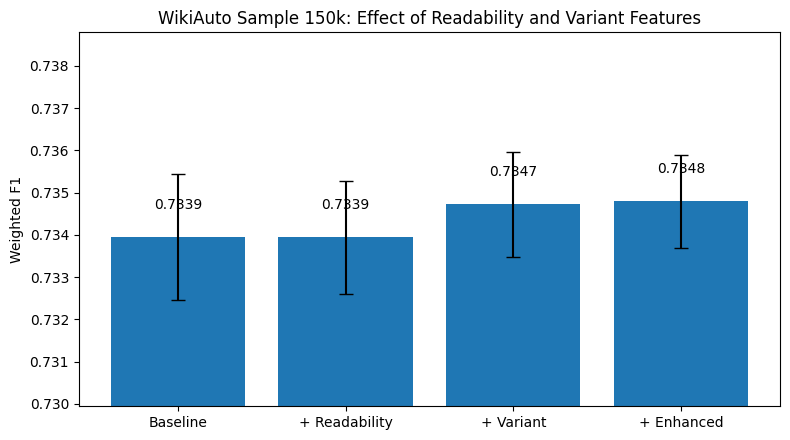

In [15]:
config_order = [
    "Baseline: Char TF-IDF + LinearSVC",
    "Baseline + Readability",
    "Baseline + Readability + Variant",
    "Baseline + Readability + Variant + Enhanced"
]

short_labels = [
    "Baseline",
    "+ Readability",
    "+ Variant",
    "+ Enhanced"
]

plot_df = (
    results_wikiauto
    .groupby("config")["weighted_f1"]
    .agg(["mean", "std"])
    .loc[config_order]
    .reset_index()
)

x = np.arange(len(plot_df))

plt.figure(figsize=(8, 4.5))

plt.bar(
    x,
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5
)

plt.xticks(x, short_labels)
plt.ylabel("Weighted F1")
plt.title("WikiAuto Sample 150k: Effect of Readability and Variant Features")

y_min = plot_df["mean"].min() - 0.004
y_max = plot_df["mean"].max() + 0.004

plt.ylim(y_min, y_max)

for i, value in enumerate(plot_df["mean"]):
    plt.text(
        i,
        value + 0.0006,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "wikiauto_weighted_f1_barplot_sample150k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()